## Georg Seismic Experiment

Explore seismic signals at Bonn

## Imports

In [1]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
import obspy as obs
import pandas as pd

from obspy.signal import PPSD

from andbro__read_sds import __read_sds
from andbro__compare_psd_stream import __compare_psd_stream

## Configurations

In [48]:
config = {}

# config['workdir'] = "/home/andbro/"
config['workdir'] = "/import/"

config['path_to_inv'] = config['workdir']+"kilauea-data/GEORG/stationxml/"

config['path_to_data'] = config['workdir']+"kilauea-data/GEORG/data/"

config['path_to_figs'] = config['workdir']+"kilauea-data/GEORG/figures/"

# loud day
config['tbeg1'] = obs.UTCDateTime("2024-12-20 00:00")
config['tend1'] = obs.UTCDateTime("2024-12-21 00:00")

# quiet day
config['tbeg2'] = obs.UTCDateTime("2024-12-25 00:00")
config['tend2'] = obs.UTCDateTime("2024-12-26 00:00")


### Seismometer Data

In [49]:
st_seis01 = __read_sds(config['path_to_data'], "XN.BONN..BH*", config['tbeg1'], config['tend1'])

inv_seis = obs.read_inventory(config['path_to_inv']+'station_XN_BONN_centaur.xml')

print(st_seis01)

3 Trace(s) in Stream:
XN.BONN..BHE | 2024-12-20T00:00:00.000000Z - 2024-12-21T00:00:00.000000Z | 40.0 Hz, 3456001 samples
XN.BONN..BHN | 2024-12-20T00:00:00.000000Z - 2024-12-21T00:00:00.000000Z | 40.0 Hz, 3456001 samples
XN.BONN..BHZ | 2024-12-20T00:00:00.000000Z - 2024-12-21T00:00:00.000000Z | 40.0 Hz, 3456001 samples


True

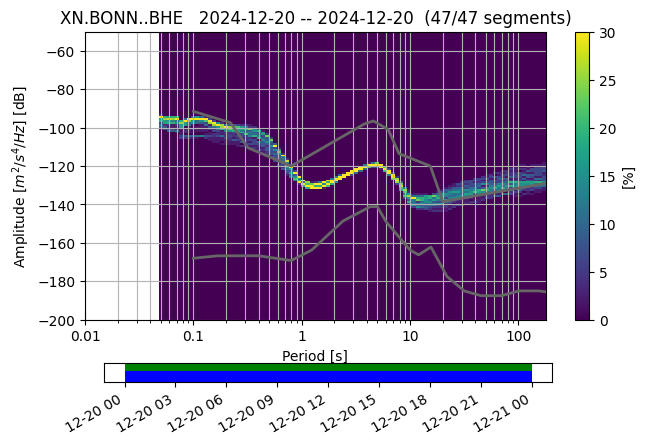

True

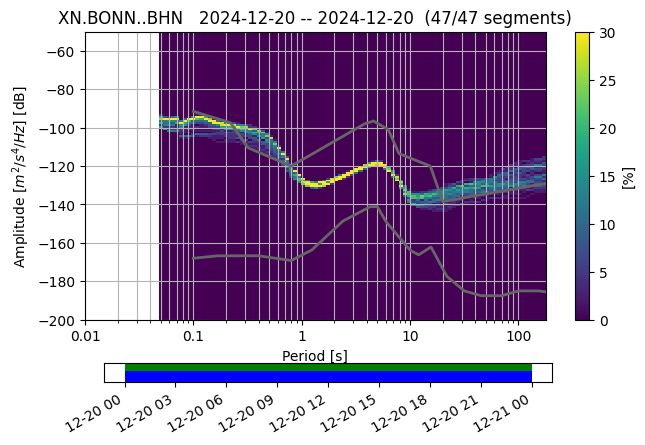

True

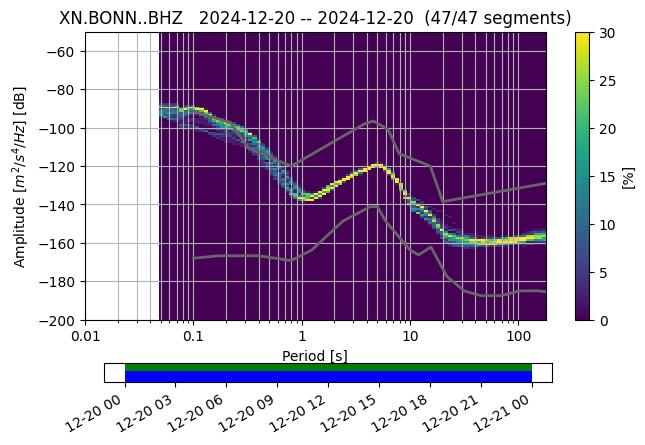

In [50]:
for tr in st_seis01:
    ppsd = obs.signal.PPSD(tr.stats, metadata=inv_seis, skip_on_gaps=True)
    ppsd.add(tr)
    ppsd.plot()

In [36]:
st_seis02 = __read_sds(config['path_to_data'], "XN.BONN..BH*", config['tbeg2'], config['tend2'])

inv_seis = obs.read_inventory(config['path_to_inv']+'station_XN_BONN_centaur.xml')

print(st_seis02)

3 Trace(s) in Stream:
XN.BONN..BHE | 2024-12-25T00:00:00.000000Z - 2024-12-26T00:00:00.000000Z | 40.0 Hz, 3456001 samples
XN.BONN..BHN | 2024-12-25T00:00:00.000000Z - 2024-12-26T00:00:00.000000Z | 40.0 Hz, 3456001 samples
XN.BONN..BHZ | 2024-12-25T00:00:00.000000Z - 2024-12-26T00:00:00.000000Z | 40.0 Hz, 3456001 samples


True

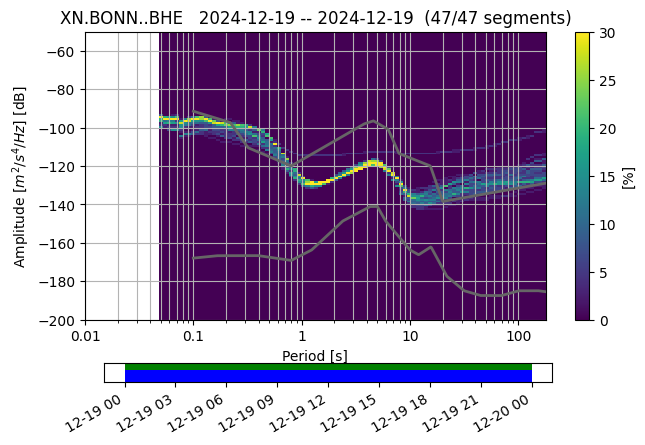

True

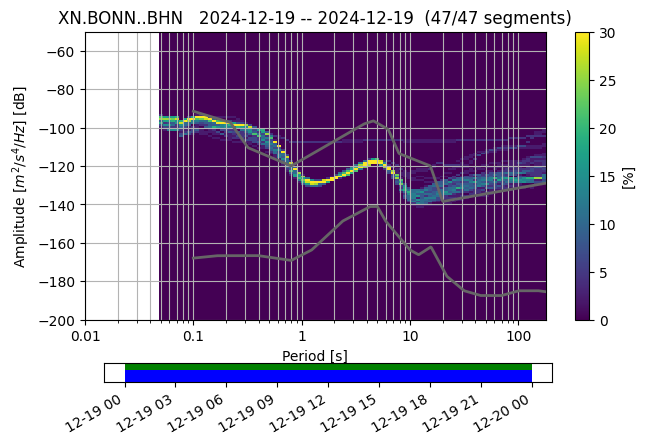

True

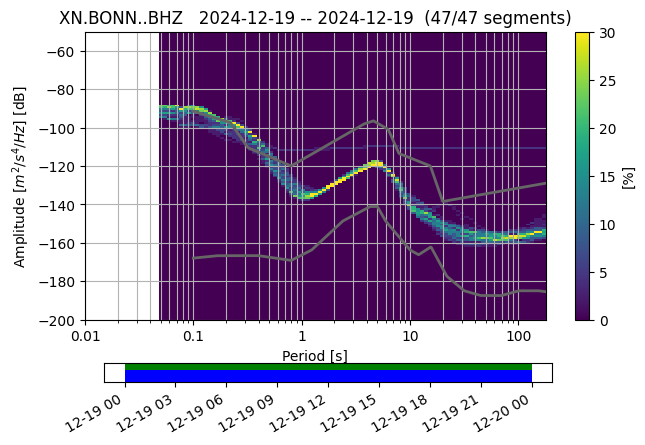

In [17]:
for tr in st_seis01:
    ppsd = obs.signal.PPSD(tr.stats, metadata=inv_seis, skip_on_gaps=True)
    ppsd.add(tr)
    ppsd.plot()

In [30]:
st_seis03 = __read_sds(config['path_to_data'], "XN.BONN..BH*", "2024-12-18", "2025-01-05")

True

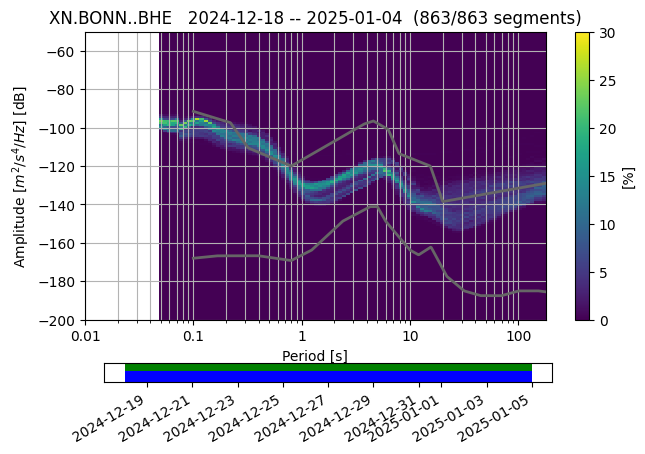

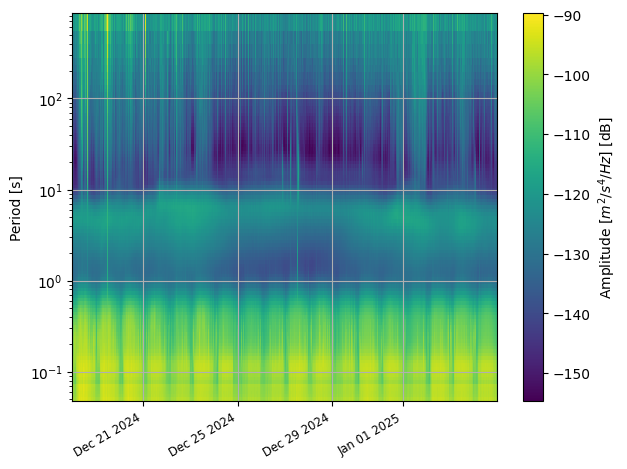

True

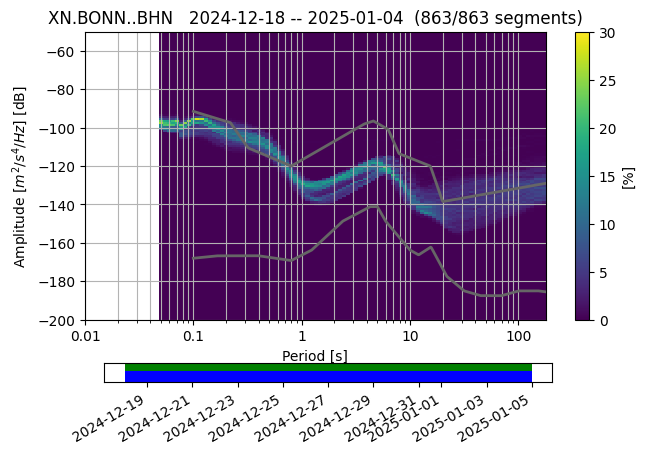

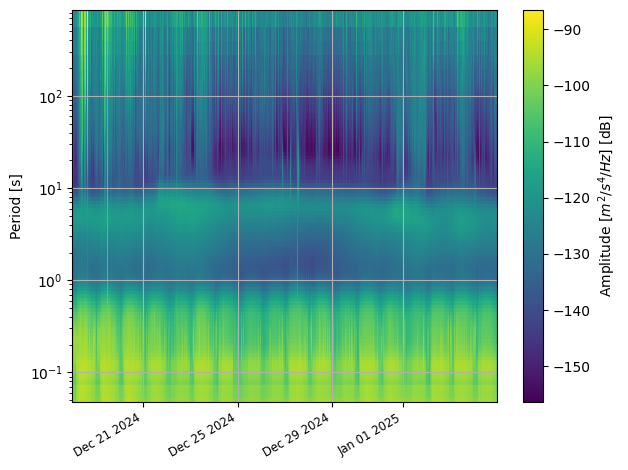

True

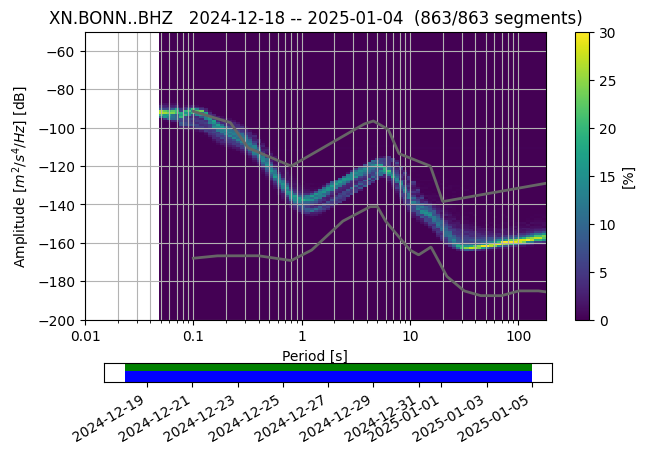

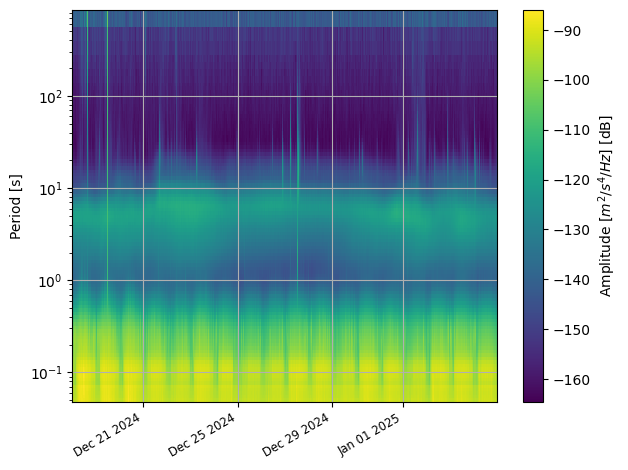

In [31]:
for tr in st_seis03:
    ppsd = obs.signal.PPSD(tr.stats, metadata=inv_seis, skip_on_gaps=True)
    ppsd.add(tr)
    ppsd.plot()
    ppsd.plot_spectrogram()

In [56]:
st_seis01x = st_seis01.copy().remove_response(inv_seis, output="ACC")

for tr in st_seis01x:
    tr.stats.location = "10"

In [57]:
st_seis02x = st_seis02.copy().remove_response(inv_seis, output="ACC")

for tr in st_seis02x:
    tr.stats.location = "20"

In [58]:
st0 = obs.Stream()
st0 += st_seis01x.copy()
st0 += st_seis02x.copy()

In [59]:
st2 = st0.copy()

st2 = st2.detrend("demean")

st2 = st2.taper(0.01)

# st2 = st2.resample(1.0, no_filter=False)

fxx, pxx = __compare_psd_stream(st2, twin_sec=7200, psd="welch", plot=False)

# fxx, pxx = __compare_psd_stream(st2, n_win=10, time_bandwidth=3.5, psd="multitaper", plot=False)

fxx2, pxx2 = __compare_psd_stream(st2, twin_sec=300, psd="welch", plot=False)


## Plotting

In [60]:
models = np.load(config['workdir']+"kilauea-data/GEORG/data/"+"noise_models.npz")

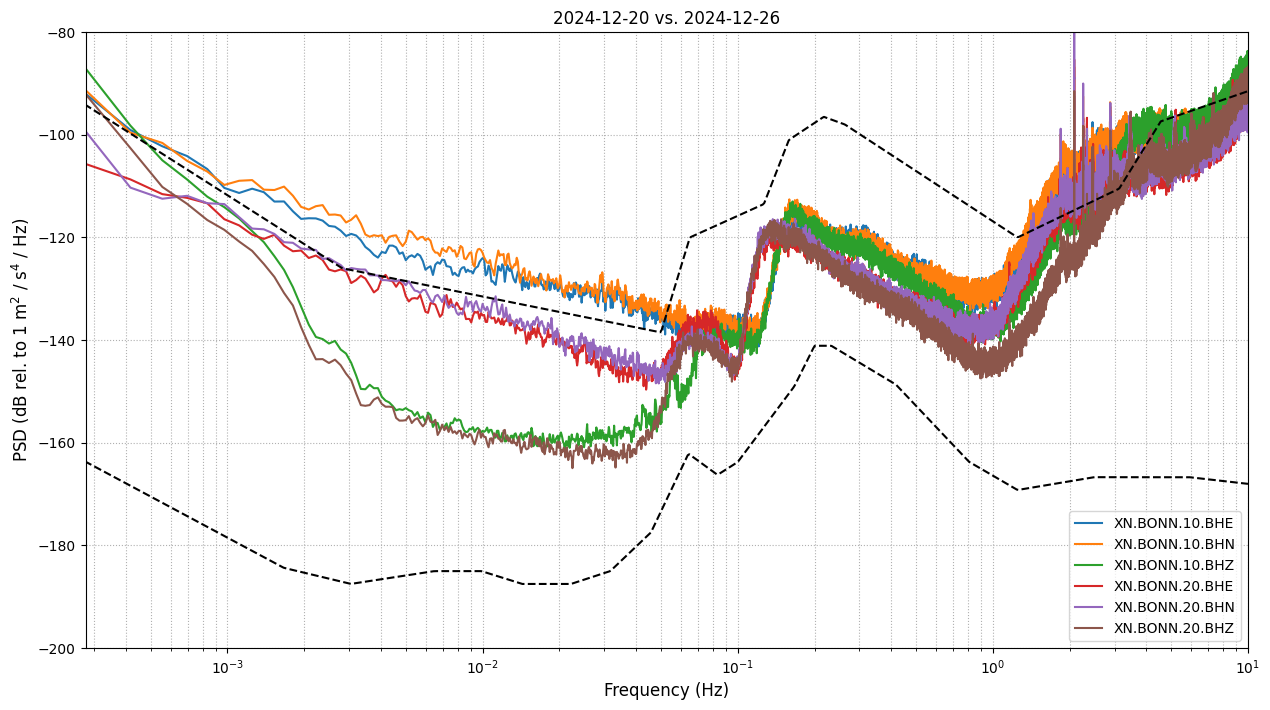

In [61]:
def makeplot():

    Nrow, Ncol = 1, 1

    font = 12

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

    for tr in st2:

        if "AM" in tr.get_id():
            continue

        ax.plot(fxx[tr.get_id()], 10*np.log10(pxx[tr.get_id()]), label=tr.get_id())

    try:
        ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
        ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")
    except:
        pass

    ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.set_ylim(-200, -80)

    ax.grid(which="both", ls=":", zorder=0)
    ax.legend(loc=4)

    fmax = 0.5/tr.stats.delta

    if fmax < 10:
        ax.set_xlim(1/3600, fmax)
    else:
        ax.set_xlim(1/3600, 10)

    ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
    ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

    ax.set_title(f"{config['tbeg1'].date} vs. {config['tend2'].date}")

    plt.show();
    return fig

fig = makeplot()

# fig.savefig(config['path_to_figs']+"PSDs.png", format="png", dpi=150, bbox_inches='tight')


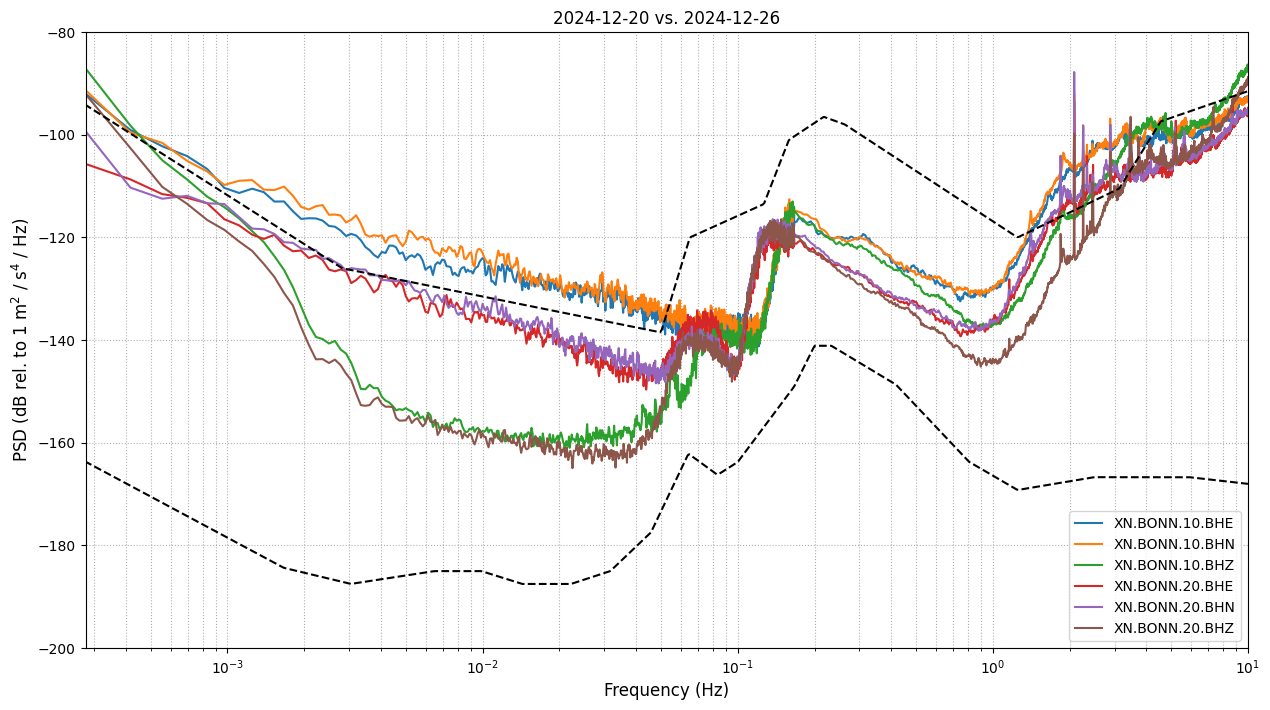

In [62]:
def makeplot2():

    Nrow, Ncol = 1, 1

    font = 12

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

    for tr in st2:

        if "AM" in tr.get_id():
            alpha = 0.25
        else:
            alpha = 1

        N = 1200
        p = ax.plot(fxx[tr.get_id()][:N],
                    10*np.log10(pxx[tr.get_id()])[:N],
                    alpha=alpha,
                   )


        N = 50
        ax.plot(fxx2[tr.get_id()][N:],
                10*np.log10(pxx2[tr.get_id()])[N:],
                label=tr.get_id(),
                color=p[0].get_color(),
               )
    try:
        ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
        ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")
    except:
        pass

    ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.set_ylim(-200, -80)

    ax.grid(which="both", ls=":", zorder=0)
    ax.legend(loc=4)

    fmax = 0.5/tr.stats.delta

    if fmax < 10:
        ax.set_xlim(1/3600, fmax)
    else:
        ax.set_xlim(1/3600, 10)

    ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
    ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

    ax.set_title(f"{config['tbeg1'].date} vs. {config['tend2'].date}")

    plt.show();
    return fig

fig = makeplot2()

# fig.savefig(config['path_to_figs']+"PSDs_split.png", format="png", dpi=150, bbox_inches='tight')
